# Полное параметрическое сканирование SIR модели

Анализ чувствительности эпидемической динамики к изменению
ключевых параметров: β_und, detection_time, death_rate и другим.

In [1]:
using DrWatson
@quickactivate "project"
using Agents, DataFrames, Plots, CSV, Statistics
include(srcdir("sir_model.jl"))

total_count (generic function with 1 method)

Полное параметрическое сканирование модели SIR.

В отличие от scan_beta.jl (где варьировался только β), здесь
перебирается небольшой грид по нескольким ключевым параметрам:
β_und, detection_time, death_rate, infection_period,
reinfection_probability. Грид сокращён (2-3 значения на параметр),
чтобы расчёт укладывался в разумное время на слабой машине.

## Функция прогона для одного набора параметров

In [2]:
function run_one(p)
    β = p[:β_und]
    model = initialize_sir(;
        Ns = [1000, 1000, 1000],
        β_und = fill(β, 3),
        β_det = fill(β / 10, 3),
        infection_period = p[:infection_period],
        detection_time = p[:detection_time],
        death_rate = p[:death_rate],
        reinfection_probability = p[:reinfection_probability],
        Is = [0, 0, 1],
        seed = p[:seed],
        n_steps = p[:n_steps],
    )

    infected_fraction(model) =
        count(a.status == :I for a in allagents(model)) / nagents(model)

    peak = 0.0
    for step in 1:p[:n_steps]
        Agents.step!(model, 1)
        frac = infected_fraction(model)
        peak = max(peak, frac)
    end

    final_inf = infected_fraction(model)
    final_rec = count(a.status == :R for a in allagents(model)) / nagents(model)
    deaths = 3000 - nagents(model)

    return (peak = peak, final_inf = final_inf, final_rec = final_rec, deaths = deaths)
end

run_one (generic function with 1 method)

## Сетка параметров (сокращённая для быстрого выполнения)

In [3]:
param_dict = Dict(
    :β_und => [0.2, 0.5],
    :detection_time => [3, 7, 14],
    :death_rate => [0.02, 0.08],
    :infection_period => [14],
    :reinfection_probability => [0.1],
    :seed => [42],
    :n_steps => [100],
)

Dict{Symbol, Vector} with 7 entries:
  :infection_period        => [14]
  :n_steps                 => [100]
  :β_und                   => [0.2, 0.5]
  :detection_time          => [3, 7, 14]
  :reinfection_probability => [0.1]
  :seed                    => [42]
  :death_rate              => [0.02, 0.08]

## Запуск сканирования

In [4]:
params_list = dict_list(param_dict)
println("Запланировано экспериментов: $(length(params_list))")

results = []
for (i, params) in enumerate(params_list)
    data = run_one(params)
    push!(results, merge(params, Dict(pairs(data))))
    println("[$i/$(length(params_list))] β=$(params[:β_und]) " *
            "detection_time=$(params[:detection_time]) " *
            "death_rate=$(params[:death_rate]) -> peak=$(round(data.peak, digits=3))")
end

Запланировано экспериментов: 12
[1/12] β=0.2 detection_time=3 death_rate=0.02 -> peak=0.001
[2/12] β=0.5 detection_time=3 death_rate=0.02 -> peak=1.0
[3/12] β=0.2 detection_time=7 death_rate=0.02 -> peak=0.995
[4/12] β=0.5 detection_time=7 death_rate=0.02 -> peak=1.0
[5/12] β=0.2 detection_time=14 death_rate=0.02 -> peak=0.999
[6/12] β=0.5 detection_time=14 death_rate=0.02 -> peak=1.0
[7/12] β=0.2 detection_time=3 death_rate=0.08 -> peak=0.001
[8/12] β=0.5 detection_time=3 death_rate=0.08 -> peak=0.998
[9/12] β=0.2 detection_time=7 death_rate=0.08 -> peak=0.997
[10/12] β=0.5 detection_time=7 death_rate=0.08 -> peak=1.0
[11/12] β=0.2 detection_time=14 death_rate=0.08 -> peak=1.0
[12/12] β=0.5 detection_time=14 death_rate=0.08 -> peak=1.0


## Сохранение результатов

In [5]:
df = DataFrame(results)
CSV.write(datadir("sir_parametric_scan_all.csv"), df)

"/home/dgavdadaev/2026-1--study--simulation-modeling/labs/lab04/project/data/sir_parametric_scan_all.csv"

## Расчёт R0 (репродуктивного числа)

In [6]:
df.gamma = 1.0 ./ df.infection_period
df.R0 = df.β_und ./ df.gamma

12-element Vector{Float64}:
 2.8000000000000003
 7.0
 2.8000000000000003
 7.0
 2.8000000000000003
 7.0
 2.8000000000000003
 7.0
 2.8000000000000003
 7.0
 2.8000000000000003
 7.0

## Визуализация: пик эпидемии в зависимости от R0

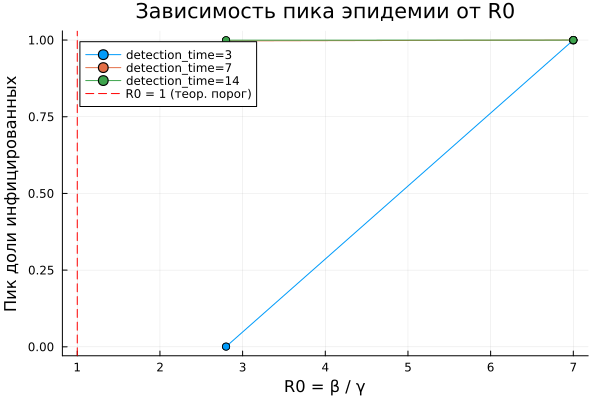

In [7]:
plt = plot(xlabel = "R0 = β / γ", ylabel = "Пик доли инфицированных",
           legend = :topleft, title = "Зависимость пика эпидемии от R0")

for dt in sort(unique(df.detection_time))
    sub = sort(df[df.detection_time .== dt, :], :R0)
    plot!(plt, sub.R0, sub.peak, marker = :circle, label = "detection_time=$dt")
end

vline!(plt, [1.0], linestyle = :dash, color = :red, label = "R0 = 1 (теор. порог)")

## Сохранение графика

In [8]:
savefig(plotsdir("sir_parametric_scan.png"))

println("Готово. Результаты: data/sir_parametric_scan_all.csv, plots/sir_parametric_scan.png")
println(df)

Готово. Результаты: data/sir_parametric_scan_all.csv, plots/sir_parametric_scan.png
12×13 DataFrame
 Row │ n_steps  final_rec    death_rate  infection_period  final_inf  β_und    detection_time  deaths  peak         reinfection_probability  seed   gamma      R0
     │ Int64    Float64      Float64     Int64             Float64    Float64  Int64           Int64   Float64      Float64                  Int64  Float64    Float64
─────┼─────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
   1 │     100  0.000666667        0.02                14   0.0           0.2               3       0  0.000666667                      0.1     42  0.0714286      2.8
   2 │     100  0.0283122          0.02                14   0.971688      0.5               3     245  1.0                              0.1     42  0.0714286      7.0
   3 │     100  0.0400976          0.02                14   0.959902 

---

*This notebook was generated using [Literate.jl](https://github.com/fredrikekre/Literate.jl).*